## 1. Load the Dataset

We load the CSV file using pandas to begin our analysis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/vle.csv')
print('Dataset loaded successfully')

Dataset loaded successfully


## 2. Dataset Shape and Column Names

Understanding the dimensions of the dataset helps us know how many rows (samples) and columns (features) we have.


In [2]:
print(f'Dataset shape: {df.shape}')
print(f'\nNumber of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')
print(f'\nColumn names:')
print(df.columns.tolist())

Dataset shape: (6364, 6)

Number of rows: 6364
Number of columns: 6

Column names:
['id_site', 'code_module', 'code_presentation', 'activity_type', 'week_from', 'week_to']


## 3. Preview First and Last Rows

Examining the first and last rows gives us a sense of the data content and structure.


In [3]:
print('First 5 rows:')
print(df.head())
print('\n' + '='*80 + '\n')
print('Last 5 rows:')
print(df.tail())

First 5 rows:
   id_site code_module code_presentation activity_type  week_from  week_to
0   546943         AAA             2013J      resource        NaN      NaN
1   546712         AAA             2013J     oucontent        NaN      NaN
2   546998         AAA             2013J      resource        NaN      NaN
3   546888         AAA             2013J           url        NaN      NaN
4   547035         AAA             2013J      resource        NaN      NaN


Last 5 rows:
      id_site code_module code_presentation activity_type  week_from  week_to
6359   897063         GGG             2014J      resource        NaN      NaN
6360   897109         GGG             2014J      resource        NaN      NaN
6361   896965         GGG             2014J     oucontent        NaN      NaN
6362   897060         GGG             2014J      resource        NaN      NaN
6363   897100         GGG             2014J      resource        NaN      NaN


## 4. Data Types

Knowing the data type of each column is crucial for determining appropriate analysis and preprocessing techniques.


In [12]:
print('Data types:')
print(df.dtypes)

Data types:
id_site                int64
code_module              str
code_presentation        str
activity_type            str
week_from            float64
week_to              float64
dtype: object


## 5. Missing Value Analysis

Identifying missing values helps us understand data quality and determine handling strategies. We check both count and percentage of missing values.


In [5]:
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) == 0:
    print('No missing values found in the dataset.')
else:
    print('Missing values:')
    print(missing_data)

Missing values:
           Missing_Count  Missing_Percentage
week_from           5243           82.385292
week_to             5243           82.385292


## 6. Duplicate Row Check

Duplicates can distort our analysis. We check for completely identical rows and rows with duplicate key identifiers.


In [6]:
# Check for completely duplicate rows
total_duplicates = df.duplicated().sum()
print(f'Total completely duplicate rows: {total_duplicates}')
print(f'Percentage of duplicates: {(total_duplicates / len(df)) * 100:.2f}%')

# Check for duplicates in each column
print('\nDuplicate counts per column:')
for col in df.columns:
    dup_count = df[col].duplicated().sum()
    if dup_count > 0:
        print(f'{col}: {dup_count} duplicates ({(dup_count/len(df))*100:.2f}%)')

Total completely duplicate rows: 0
Percentage of duplicates: 0.00%

Duplicate counts per column:
code_module: 6357 duplicates (99.89%)
code_presentation: 6360 duplicates (99.94%)
activity_type: 6344 duplicates (99.69%)
week_from: 6333 duplicates (99.51%)
week_to: 6333 duplicates (99.51%)


## 7. Summary Statistics for Numeric Columns

Descriptive statistics provide insights into the distribution, central tendency, and spread of numeric features.


In [ ]:
print('Summary statistics for numeric columns:')
print(df.describe())

Summary statistics for numeric columns:
            id_site    week_from      week_to
count  6.364000e+03  1121.000000  1121.000000
mean   7.260991e+05    15.204282    15.214987
std    1.283151e+05     8.792865     8.779806
min    5.267210e+05     0.000000     0.000000
25%    6.615928e+05     8.000000     8.000000
50%    7.300965e+05    15.000000    15.000000
75%    8.140162e+05    22.000000    22.000000
max    1.077905e+06    29.000000    29.000000


Additional statistics:
id_site: skewness = -0.140, kurtosis = -0.931
week_from: skewness = -0.096, kurtosis = -1.193
week_to: skewness = -0.095, kurtosis = -1.192


## 8. Overview of Categorical Columns

For categorical columns, we examine unique counts and sample values to understand categorical diversity.


In [8]:
categorical_cols = df.select_dtypes(include=['object']).columns

if len(categorical_cols) > 0:
    for col in categorical_cols:
        print(f'{col}:')
        print(f'  Unique values: {df[col].nunique()}')
        print(f'  Sample values: {df[col].unique()[:5]}')
        print()
else:
    print('No categorical columns found in the dataset.')

code_module:
  Unique values: 7
  Sample values: <StringArray>
['AAA', 'BBB', 'CCC', 'DDD', 'EEE']
Length: 5, dtype: str

code_presentation:
  Unique values: 4
  Sample values: <StringArray>
['2013J', '2014J', '2013B', '2014B']
Length: 4, dtype: str

activity_type:
  Unique values: 20
  Sample values: <StringArray>
['resource', 'oucontent', 'url', 'homepage', 'subpage']
Length: 5, dtype: str



C:\Users\Dell\AppData\Local\Temp\ipykernel_26932\1950261300.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


## 9. Value Counts for Key Categorical or Target-like Columns

Detailed frequency analysis of categorical columns helps us identify class distributions and potential imbalances.


In [9]:
for col in categorical_cols:
    print(f'Value counts for {col}:')
    print(df[col].value_counts())
    print(f'\nPercentage distribution:')
    print(df[col].value_counts(normalize=True) * 100)
    print('\n' + '='*80 + '\n')

Value counts for code_module:
code_module
FFF    1967
DDD    1708
BBB    1154
CCC     419
AAA     413
GGG     367
EEE     336
Name: count, dtype: int64

Percentage distribution:
code_module
FFF    30.908234
DDD    26.838466
BBB    18.133250
CCC     6.583909
AAA     6.489629
GGG     5.766813
EEE     5.279698
Name: proportion, dtype: float64


Value counts for code_presentation:
code_presentation
2013J    1772
2014B    1671
2014J    1670
2013B    1251
Name: count, dtype: int64

Percentage distribution:
code_presentation
2013J    27.844123
2014B    26.257071
2014J    26.241358
2013B    19.657448
Name: proportion, dtype: float64


Value counts for activity_type:
activity_type
resource          2660
subpage           1055
oucontent          996
url                886
forumng            194
quiz               127
page               102
oucollaborate       82
questionnaire       61
ouwiki              49
dataplus            28
externalquiz        26
homepage            22
glossary            

## 10. Activity Type Distribution Analysis

Analyzing how different activity types are distributed across modules and presentations helps understand the composition and variety of learning activities offered in the VLE.


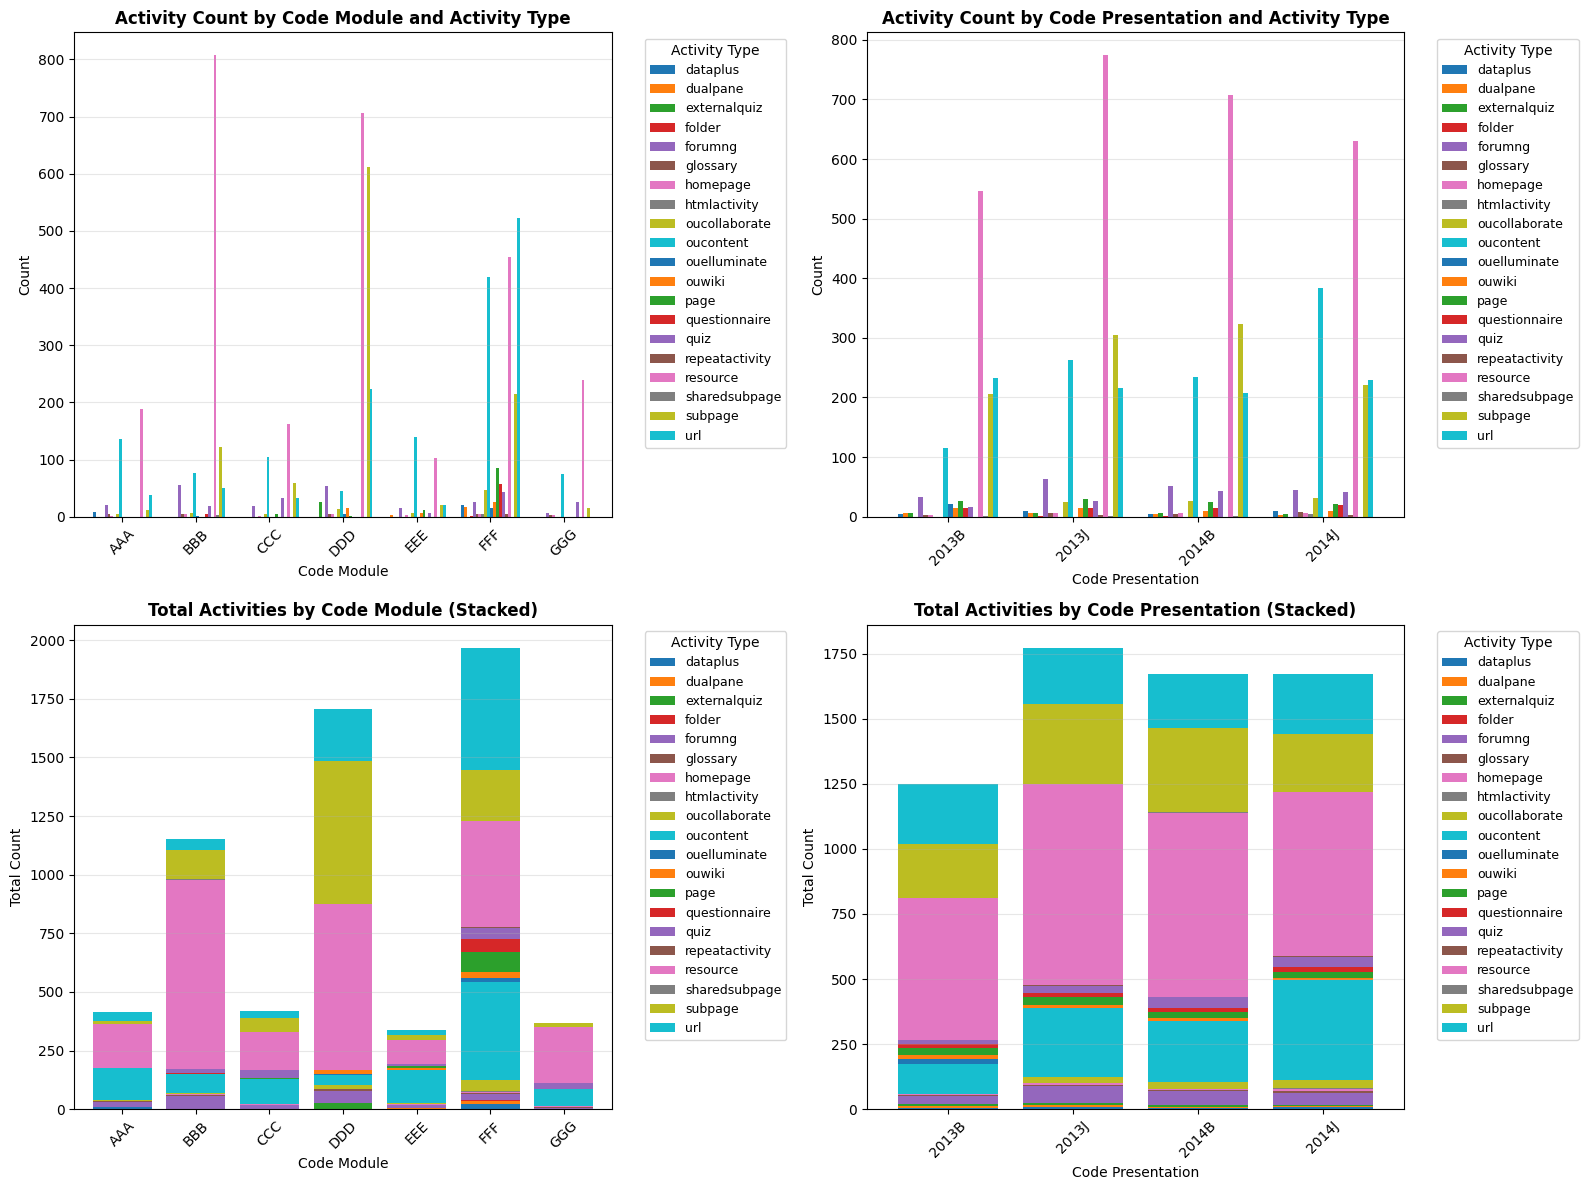

In [14]:
# Activity Type Distribution Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Activity count by activity type and code module
activity_module = df.pivot_table(values='id_site', index='code_module', columns='activity_type', aggfunc='count')
activity_module.plot(kind='bar', ax=axes[0, 0], width=0.8)
axes[0, 0].set_title('Activity Count by Code Module and Activity Type', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Code Module')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(title='Activity Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Activity count by activity type and code presentation
activity_presentation = df.pivot_table(values='id_site', index='code_presentation', columns='activity_type', aggfunc='count')
activity_presentation.plot(kind='bar', ax=axes[0, 1], width=0.8)
axes[0, 1].set_title('Activity Count by Code Presentation and Activity Type', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Code Presentation')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(title='Activity Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Stacked bar chart - Total activities by code module
activity_module_stacked = df.pivot_table(values='id_site', index='code_module', columns='activity_type', aggfunc='count')
activity_module_stacked.plot(kind='bar', ax=axes[1, 0], width=0.8, stacked=True)
axes[1, 0].set_title('Total Activities by Code Module (Stacked)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Code Module')
axes[1, 0].set_ylabel('Total Count')
axes[1, 0].legend(title='Activity Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Stacked bar chart - Total activities by code presentation
activity_presentation_stacked = df.pivot_table(values='id_site', index='code_presentation', columns='activity_type', aggfunc='count')
activity_presentation_stacked.plot(kind='bar', ax=axes[1, 1], width=0.8, stacked=True)
axes[1, 1].set_title('Total Activities by Code Presentation (Stacked)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Code Presentation')
axes[1, 1].set_ylabel('Total Count')
axes[1, 1].legend(title='Activity Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
